In [1]:
# Retail Profit Optimization: A Cost and Performance Analysis

In [2]:
from IPython.display import Markdown, display

display(Markdown("""
# Retail Profit Optimization: A Cost and Performance Analysis

Problem Definition🎯 :
This project is designed for retail managers and small business owners who want to improve profitability.

The main question is:
**How can a retail business identify loss-making products and optimise its cost structure to improve overall profitability?**

This notebook uses Python to clean, analyse, and visualise retail sales data, with the goal of generating actionable business insights.
"""))


# Retail Profit Optimization: A Cost and Performance Analysis

Problem Definition🎯 :
This project is designed for retail managers and small business owners who want to improve profitability.

The main question is:
**How can a retail business identify loss-making products and optimise its cost structure to improve overall profitability?**

This notebook uses Python to clean, analyse, and visualise retail sales data, with the goal of generating actionable business insights.


In [3]:
# Import the libraries needed for data analysis and visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Set the plotting style for clearer charts

plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
# Load the dataset into Python

file_path = "data.sample.superstore.csv"
df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded successfully.
Rows: 9994, Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Check the column names in the dataset

df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
# Inspect the dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
# Check missing values in each column

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Remove duplicate rows and convert the order date to datetime format

df = df.drop_duplicates()
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
# Preview the cleaned dataset

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
# Create profit margin and time-related variables for further analysis

df = df[df["Sales"] != 0].copy()
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Year,Month,Month Name,Year-Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,2016,11,Nov,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,2016,11,Nov,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,2016,6,Jun,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,2015,10,Oct,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,2015,10,Oct,2015-10


In [12]:
# Calculate the overall business performance

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_margin = df["Profit Margin"].mean()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Profit Margin: {avg_margin:.2%}")

Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Profit Margin: 12.03%


In [13]:
# Summarise sales and profit by category

category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Profit", ascending=False)
)

category_summary["Profit Margin"] = category_summary["Profit"] / category_summary["Sales"]
category_summary

,Sales,Profit,Profit Margin
Category,,,
Technology,836154.0330,145454.9481,0.173957
Office Supplies,719047.0320,122490.8008,0.170352
Furniture,741999.7953,18451.2728,0.024867


In [14]:
# Summarise sales and profit by sub-category

subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Profit")
)

subcategory_summary["Profit Margin"] = subcategory_summary["Profit"] / subcategory_summary["Sales"]
subcategory_summary

,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Supplies,46673.5380,-1189.0995,-0.025477
Fasteners,3024.2800,949.5182,0.313965
Machines,189238.6310,3384.7569,0.017886
Labels,12486.3120,5546.2540,0.444187
Art,27118.7920,6527.7870,0.240711
Envelopes,16476.4020,6964.1767,0.422676
Furnishings,91705.1640,13059.1436,0.142404


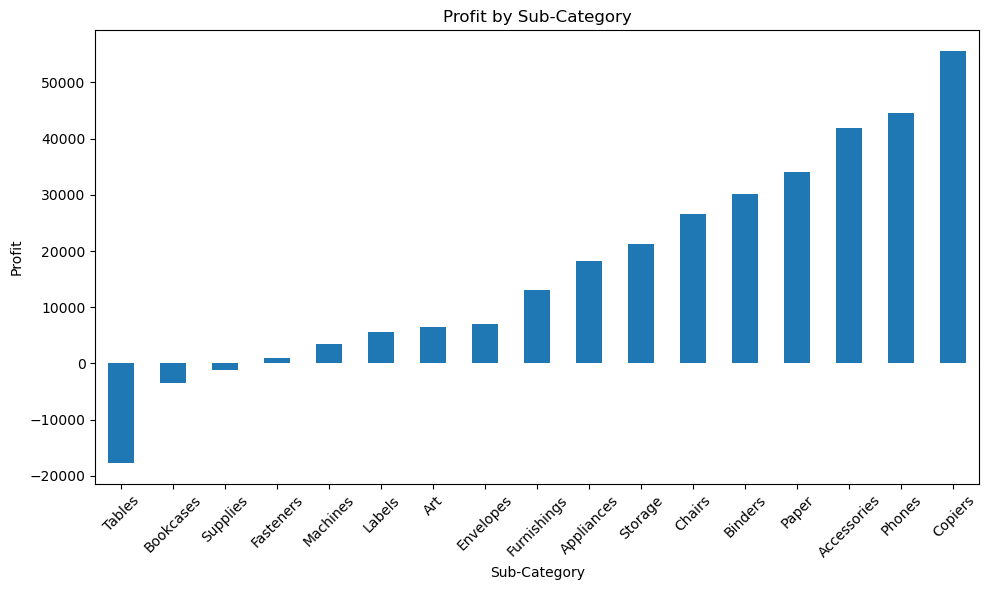

In [15]:
# Visualise profit by sub-category

subcategory_summary["Profit"].plot(kind="bar")
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Identify the loss-making sub-categories

loss_products = subcategory_summary[subcategory_summary["Profit"] < 0]
loss_products

,Sales,Profit,Profit Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-0.085645
Bookcases,114879.9963,-3472.5560,-0.030228
Supplies,46673.5380,-1189.0995,-0.025477


In [17]:
# Provide recommendations based on product performance

print("Recommendation:")
print("- Review the pricing strategy for loss-making sub-categories")
print("- Reduce excessive discounting on low-profit products")
print("- Focus more resources on high-margin product groups")

Recommendation:
- Review the pricing strategy for loss-making sub-categories
- Reduce excessive discounting on low-profit products
- Focus more resources on high-margin product groups


In [18]:
# Summarise sales and profit by region

region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Profit", ascending=False)
)

region_summary["Profit Margin"] = region_summary["Profit"] / region_summary["Sales"]
region_summary

,Sales,Profit,Profit Margin
Region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
Central,501239.8908,39706.3625,0.079216


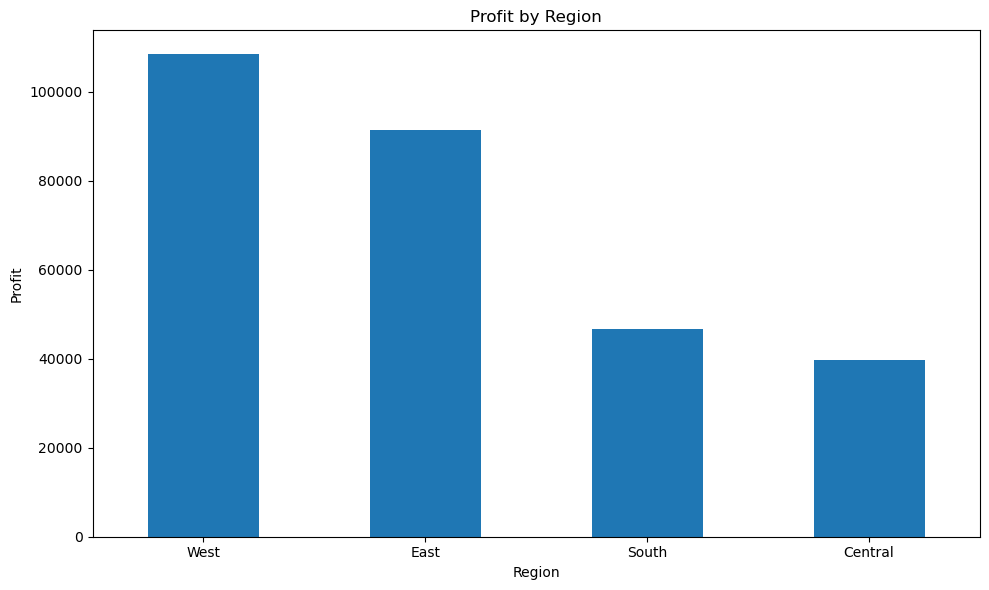

In [19]:
# Visualise profit by region

region_summary["Profit"].plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

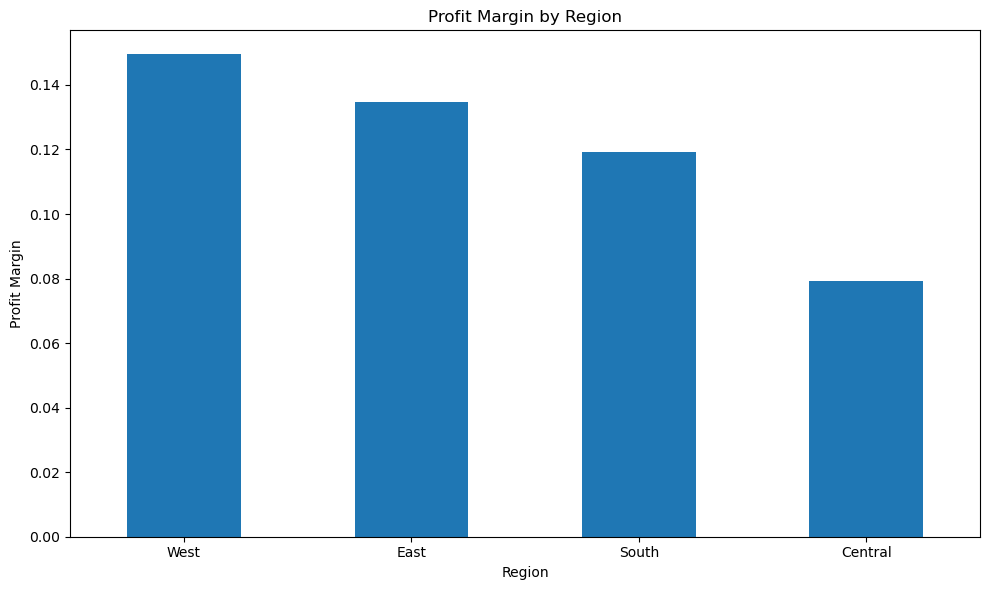

In [20]:
# Visualise profit margin by region

region_summary["Profit Margin"].plot(kind="bar")
plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Provide recommendations based on regional performance

print("Recommendation:")
print("- Focus on high-performing regions to increase profitability")
print("- Investigate cost inefficiencies in low-performing regions")
print("- Use profit margin as well as sales when evaluating regional performance")

Recommendation:
- Focus on high-performing regions to increase profitability
- Investigate cost inefficiencies in low-performing regions
- Use profit margin as well as sales when evaluating regional performance


In [22]:
# Summarise monthly sales, profit and profit margin with readable month labels

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_summary = (
    df.groupby("Month Name")[["Sales", "Profit"]]
    .sum()
    .reindex(month_order)
)

monthly_summary["Profit Margin"] = monthly_summary["Profit"] / monthly_summary["Sales"]

monthly_summary

,Sales,Profit,Profit Margin
Month Name,,,
Jan,94924.8356,9134.4461,0.096228
Feb,59751.2514,10294.6107,0.172291
Mar,205005.4888,28594.6872,0.139483
Apr,137762.1286,11587.4363,0.084112
May,155028.8117,22411.3078,0.144562
Jun,152718.6793,21285.7954,0.139379
Jul,147238.0970,13832.6648,0.093948
Aug,159044.0630,21776.9384,0.136924
Sep,307649.9457,36857.4753,0.119803


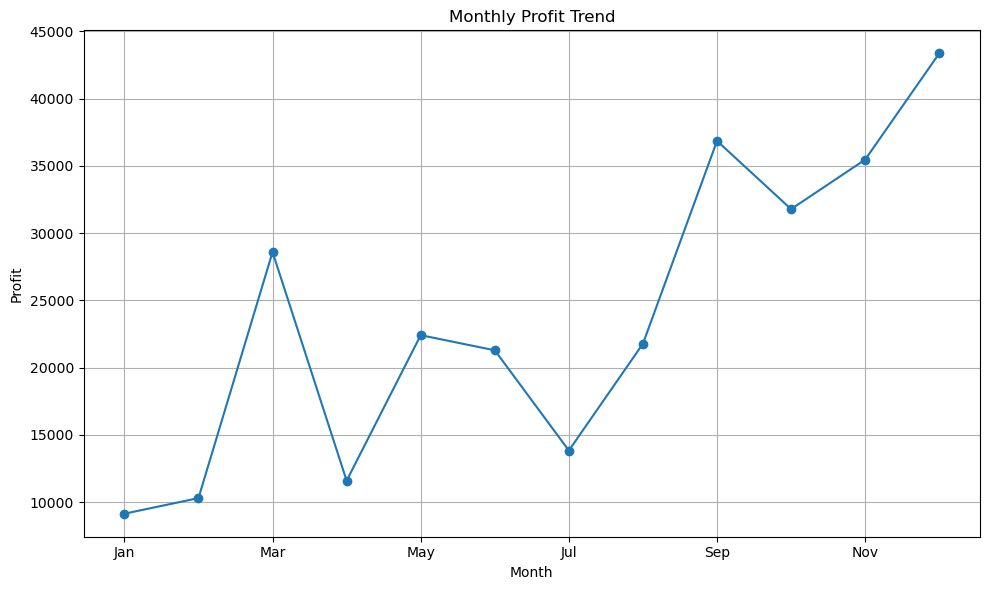

In [23]:
# Plot monthly profit trend

monthly_summary["Profit"].plot(kind="line", marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid()
plt.tight_layout()
plt.show()

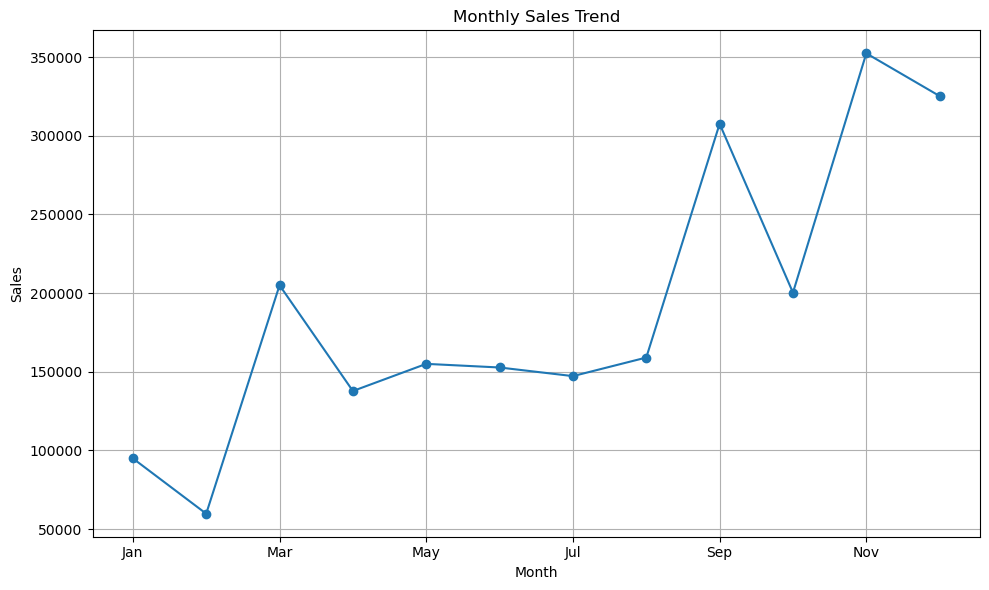

In [24]:
# Plot monthly sales trend

monthly_summary["Sales"].plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.tight_layout()
plt.show()

In [25]:
# Provide recommendations based on monthly performance

best_month = monthly_summary["Profit"].idxmax()
worst_month = monthly_summary["Profit"].idxmin()

print("Time Trend Insights:")
print(f"- The most profitable month is: {best_month}")
print(f"- The least profitable month is: {worst_month}")

print("\nRecommendations:")
print("- Increase inventory before high-profit months")
print("- Improve promotions and cost control during low-profit months")
print("- Use seasonal trends for planning and budgeting")

Time Trend Insights:
- The most profitable month is: Dec
- The least profitable month is: Jan

Recommendations:
- Increase inventory before high-profit months
- Improve promotions and cost control during low-profit months
- Use seasonal trends for planning and budgeting


In [26]:
# Combine product, regional, and time insights to support business decisions

best_category = df.groupby("Category")["Profit"].sum().idxmax()
worst_subcategory = df.groupby("Sub-Category")["Profit"].sum().idxmin()
best_region = region_summary["Profit"].idxmax()
best_month = monthly_summary["Profit"].idxmax()

print("Integrated Business Insights:")
print(f"- Most profitable category: {best_category}")
print(f"- Least profitable sub-category: {worst_subcategory}")
print(f"- Best-performing region: {best_region}")
print(f"- Most profitable month: {best_month}")

print("\nOverall Strategic Recommendations:")
print("- Focus on high-profit categories in strong-performing regions")
print("- Reduce or improve loss-making sub-categories")
print("- Increase inventory and marketing before high-profit months")
print("- Align product strategy with regional demand and seasonal patterns")

Integrated Business Insights:
- Most profitable category: Technology
- Least profitable sub-category: Tables
- Best-performing region: West
- Most profitable month: Dec

Overall Strategic Recommendations:
- Focus on high-profit categories in strong-performing regions
- Reduce or improve loss-making sub-categories
- Increase inventory and marketing before high-profit months
- Align product strategy with regional demand and seasonal patterns
